In [2]:
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

import uproot

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (7, 4)

In [3]:
madgraph5_end_to_end_file_path = '/data/gmajeri/diquark-simulations/signal/ATLAS_Suu_chichi_WbWb_MSuu_7.5TeV/Events/run_01/tag_1_delphes_events.root'

with uproot.open(madgraph5_end_to_end_file_path) as f:
    tree = f["Delphes"]

print(tree.keys())

['Event', 'Event/Event.fUniqueID', 'Event/Event.fBits', 'Event/Event.Number', 'Event/Event.ReadTime', 'Event/Event.ProcTime', 'Event/Event.ProcessID', 'Event/Event.MPI', 'Event/Event.Weight', 'Event/Event.CrossSection', 'Event/Event.CrossSectionError', 'Event/Event.Scale', 'Event/Event.AlphaQED', 'Event/Event.AlphaQCD', 'Event/Event.ID1', 'Event/Event.ID2', 'Event/Event.X1', 'Event/Event.X2', 'Event/Event.ScalePDF', 'Event/Event.PDF1', 'Event/Event.PDF2', 'Event_size', 'Weight', 'Weight/Weight.fUniqueID', 'Weight/Weight.fBits', 'Weight/Weight.Weight', 'Weight_size', 'Particle', 'Particle/Particle.fUniqueID', 'Particle/Particle.fBits', 'Particle/Particle.PID', 'Particle/Particle.Status', 'Particle/Particle.IsPU', 'Particle/Particle.M1', 'Particle/Particle.M2', 'Particle/Particle.D1', 'Particle/Particle.D2', 'Particle/Particle.Charge', 'Particle/Particle.Mass', 'Particle/Particle.E', 'Particle/Particle.Px', 'Particle/Particle.Py', 'Particle/Particle.Pz', 'Particle/Particle.P', 'Particle/

In [4]:
def compute_invariant_mass(tree: uproot.TBranch):
    # Extract jet 4-vector components
    p_T = tree["Jet/Jet.PT"].array()
    eta = tree["Jet/Jet.Eta"].array()
    phi = tree["Jet/Jet.Phi"].array()

    # Compute components in Cartesian coordinates
    p_x = p_T * np.cos(phi)
    p_y = p_T * np.sin(phi)
    p_z = p_T * np.sinh(eta)

    # Compute jet energy
    energy = p_T * np.cosh(eta)

    # Compute the total momentum (sum of jet momenta)
    p_x_total = ak.sum(p_x, axis=-1).to_numpy()
    p_y_total = ak.sum(p_y, axis=-1).to_numpy()
    p_z_total = ak.sum(p_z, axis=-1).to_numpy()

    # Compute the total event energy
    total_energy = ak.sum(energy, axis=-1).to_numpy()

    # Compute the square of the total invariant mass of the particles
    total_mass_squared = (
        # |sum energies|^2 - ||sum momentum vectors||^2
        total_energy**2 - p_x_total**2 - p_y_total**2 - p_z_total**2
    )

    mass = np.sqrt(
        total_mass_squared,
        out=np.zeros_like(total_energy, dtype=np.float64),
        where=total_mass_squared >= 0,
    )

    return np.nan_to_num(mass)

In [4]:
compute_invariant_mass(tree)

array([7097.875     , 6768.01904297, 6765.44824219, ..., 7156.56103516,
       6005.43310547, 6712.76025391], shape=(30000,))

In [8]:
def plot_combined_invariant_mass(tree, ymin=0, ymax=6500):
    invariant_mass = compute_invariant_mass(tree)
    plt.title("Combined jets invariant mass")
    plt.hist(invariant_mass, bins=30)
    mean = invariant_mass.mean()
    plt.vlines(mean, ymin, ymax, color='red', label=f'Mean = {mean:.2f}')
    plt.legend()
    plt.grid()
    plt.show()

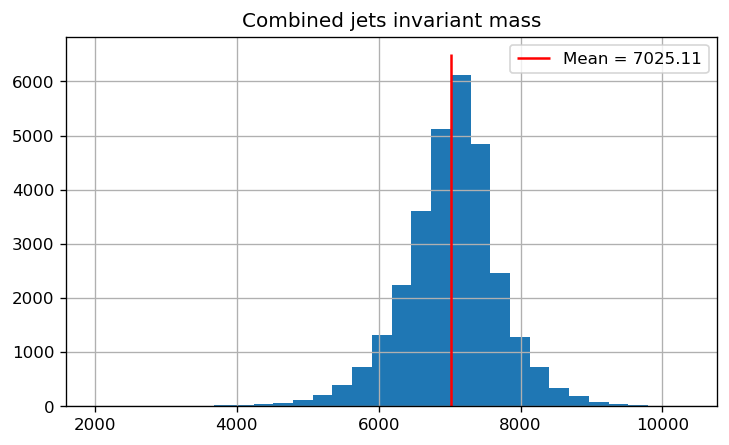

In [6]:
plot_combined_invariant_mass(tree)

In [7]:
madgraph5_manual_file_path = '/data/gmajeri/diquark-simulations/signal/ATLAS_Suu_chichi_WbWb_MSuu_7.5TeV_no_showering/Events/run_01/detected_events.root'

with uproot.open(madgraph5_manual_file_path) as f:
    tree = f["Delphes"]

print(tree.keys())

['Event', 'Event/Event.fUniqueID', 'Event/Event.fBits', 'Event/Event.Number', 'Event/Event.ReadTime', 'Event/Event.ProcTime', 'Event/Event.ProcessID', 'Event/Event.MPI', 'Event/Event.Weight', 'Event/Event.CrossSection', 'Event/Event.CrossSectionError', 'Event/Event.Scale', 'Event/Event.AlphaQED', 'Event/Event.AlphaQCD', 'Event/Event.ID1', 'Event/Event.ID2', 'Event/Event.X1', 'Event/Event.X2', 'Event/Event.ScalePDF', 'Event/Event.PDF1', 'Event/Event.PDF2', 'Event_size', 'Weight', 'Weight/Weight.fUniqueID', 'Weight/Weight.fBits', 'Weight/Weight.Weight', 'Weight_size', 'Particle', 'Particle/Particle.fUniqueID', 'Particle/Particle.fBits', 'Particle/Particle.PID', 'Particle/Particle.Status', 'Particle/Particle.IsPU', 'Particle/Particle.M1', 'Particle/Particle.M2', 'Particle/Particle.D1', 'Particle/Particle.D2', 'Particle/Particle.Charge', 'Particle/Particle.Mass', 'Particle/Particle.E', 'Particle/Particle.Px', 'Particle/Particle.Py', 'Particle/Particle.Pz', 'Particle/Particle.P', 'Particle/

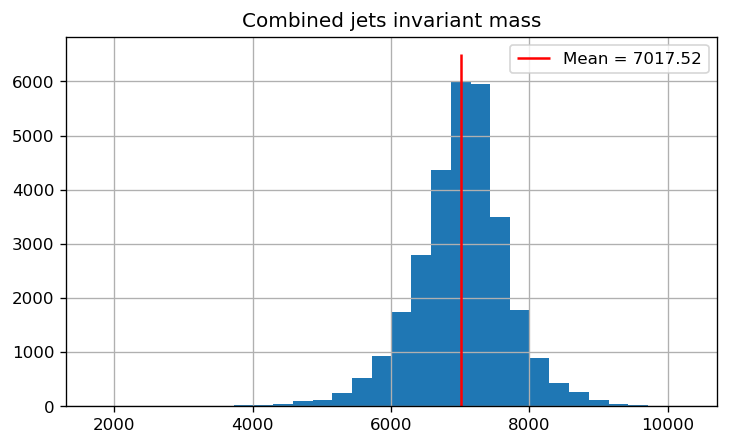

In [8]:
plot_combined_invariant_mass(tree)

In [9]:
madgraph5_ioana_signal_path = '/data/gmajeri/diquark-simulations/signal/ATLAS_ioana_signal/detected_events_signal_ioana.root'

with uproot.open(madgraph5_ioana_signal_path) as f:
    tree = f["Delphes"]

print(tree.keys())

['Event', 'Event/Event.fUniqueID', 'Event/Event.fBits', 'Event/Event.Number', 'Event/Event.ReadTime', 'Event/Event.ProcTime', 'Event/Event.ProcessID', 'Event/Event.MPI', 'Event/Event.Weight', 'Event/Event.CrossSection', 'Event/Event.CrossSectionError', 'Event/Event.Scale', 'Event/Event.AlphaQED', 'Event/Event.AlphaQCD', 'Event/Event.ID1', 'Event/Event.ID2', 'Event/Event.X1', 'Event/Event.X2', 'Event/Event.ScalePDF', 'Event/Event.PDF1', 'Event/Event.PDF2', 'Event_size', 'Weight', 'Weight/Weight.fUniqueID', 'Weight/Weight.fBits', 'Weight/Weight.Weight', 'Weight_size', 'Particle', 'Particle/Particle.fUniqueID', 'Particle/Particle.fBits', 'Particle/Particle.PID', 'Particle/Particle.Status', 'Particle/Particle.IsPU', 'Particle/Particle.M1', 'Particle/Particle.M2', 'Particle/Particle.D1', 'Particle/Particle.D2', 'Particle/Particle.Charge', 'Particle/Particle.Mass', 'Particle/Particle.E', 'Particle/Particle.Px', 'Particle/Particle.Py', 'Particle/Particle.Pz', 'Particle/Particle.P', 'Particle/

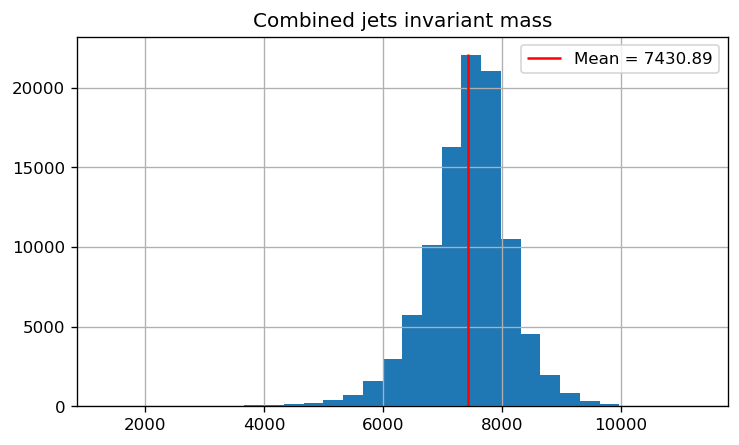

In [18]:
plot_combined_invariant_mass(tree, ymax=22100)

In [19]:
madgraph5_old_signal_path = '/data/iduminic/diquark-signal/ATLAS_SGN/Chichi_FullHadro/ATLAS_Full_Hadr_100k_136TeV_ChiChi_Wb_Wb/Events/run_MSuu_136TeV_80/tag_1_delphes_events.root'

with uproot.open(madgraph5_old_signal_path) as f:
    tree = f["Delphes"]

print(tree.keys())

['Event', 'Event/Event.fUniqueID', 'Event/Event.fBits', 'Event/Event.Number', 'Event/Event.ReadTime', 'Event/Event.ProcTime', 'Event/Event.ProcessID', 'Event/Event.MPI', 'Event/Event.Weight', 'Event/Event.CrossSection', 'Event/Event.CrossSectionError', 'Event/Event.Scale', 'Event/Event.AlphaQED', 'Event/Event.AlphaQCD', 'Event/Event.ID1', 'Event/Event.ID2', 'Event/Event.X1', 'Event/Event.X2', 'Event/Event.ScalePDF', 'Event/Event.PDF1', 'Event/Event.PDF2', 'Event_size', 'Weight', 'Weight/Weight.fUniqueID', 'Weight/Weight.fBits', 'Weight/Weight.Weight', 'Weight_size', 'Particle', 'Particle/Particle.fUniqueID', 'Particle/Particle.fBits', 'Particle/Particle.PID', 'Particle/Particle.Status', 'Particle/Particle.IsPU', 'Particle/Particle.M1', 'Particle/Particle.M2', 'Particle/Particle.D1', 'Particle/Particle.D2', 'Particle/Particle.Charge', 'Particle/Particle.Mass', 'Particle/Particle.E', 'Particle/Particle.Px', 'Particle/Particle.Py', 'Particle/Particle.Pz', 'Particle/Particle.P', 'Particle/

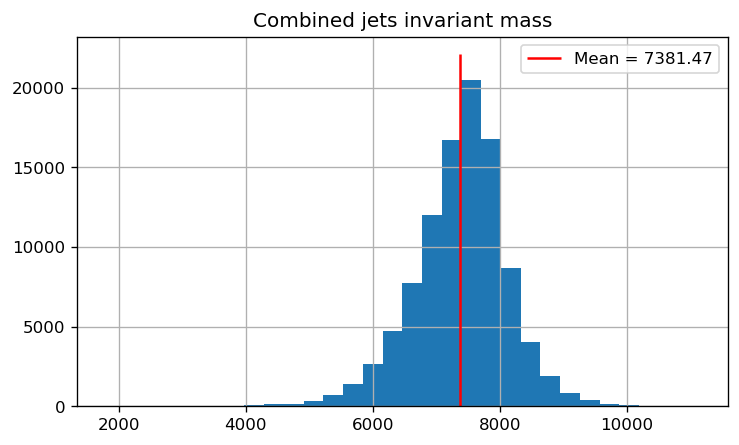

In [20]:
plot_combined_invariant_mass(tree, ymax=22100)

In [5]:
madgraph5_with_mhatmin_path = '/data/gmajeri/diquark-simulations/background/ATLAS_data_136_ttbar_MSuu_8TeV_mHatMin/Events/run_ttbar/tag_1_delphes_events.root'

with uproot.open(madgraph5_with_mhatmin_path) as f:
    tree = f["Delphes"]

print(tree.keys())

['Event', 'Event/Event.fUniqueID', 'Event/Event.fBits', 'Event/Event.Number', 'Event/Event.ReadTime', 'Event/Event.ProcTime', 'Event/Event.ProcessID', 'Event/Event.MPI', 'Event/Event.Weight', 'Event/Event.CrossSection', 'Event/Event.CrossSectionError', 'Event/Event.Scale', 'Event/Event.AlphaQED', 'Event/Event.AlphaQCD', 'Event/Event.ID1', 'Event/Event.ID2', 'Event/Event.X1', 'Event/Event.X2', 'Event/Event.ScalePDF', 'Event/Event.PDF1', 'Event/Event.PDF2', 'Event_size', 'Weight', 'Weight/Weight.fUniqueID', 'Weight/Weight.fBits', 'Weight/Weight.Weight', 'Weight_size', 'Particle', 'Particle/Particle.fUniqueID', 'Particle/Particle.fBits', 'Particle/Particle.PID', 'Particle/Particle.Status', 'Particle/Particle.IsPU', 'Particle/Particle.M1', 'Particle/Particle.M2', 'Particle/Particle.D1', 'Particle/Particle.D2', 'Particle/Particle.Charge', 'Particle/Particle.Mass', 'Particle/Particle.E', 'Particle/Particle.Px', 'Particle/Particle.Py', 'Particle/Particle.Pz', 'Particle/Particle.P', 'Particle/

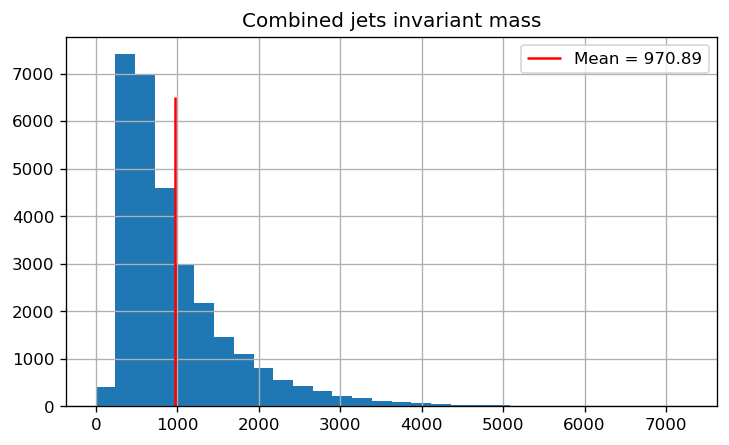

In [9]:
plot_combined_invariant_mass(tree)